<a href="https://colab.research.google.com/github/epmbanten/Tugas-AI-602225073-Dody-Suhendra/blob/main/ANFIS_Load_Forecasting_Synthetic_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# ANFIS Load Forecasting with Synthetic Data

Notebook ini siap dijalankan di Google Colab.

Isi notebook:
- Membuat dataset sintetis beban listrik
- Melatih model ANFIS sederhana
- Evaluasi model
- Visualisasi hasil
- Prediksi data baru
- Menyimpan model dan scaler


In [1]:

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


In [2]:

# Membuat dataset sintetis beban listrik
# Fitur:
# hour        = jam 0..23
# temperature = suhu harian
# day_type    = 0 untuk weekday, 1 untuk weekend

n_days = 240
rows = []

for day in range(n_days):
    day_type = 1 if day % 7 in [5, 6] else 0
    base_temp = 28 + 4 * np.sin(2 * np.pi * day / 30) + np.random.normal(0, 0.8)

    for hour in range(24):
        temp = base_temp + 3 * np.sin(2 * np.pi * (hour - 13) / 24) + np.random.normal(0, 0.4)

        morning_peak = 18 * np.exp(-((hour - 8) ** 2) / 10)
        evening_peak = 28 * np.exp(-((hour - 19) ** 2) / 12)
        temp_effect = max(temp - 26, 0) * 3.2
        weekend_effect = -10 if day_type == 1 else 0
        base_load = 55

        load = (
            base_load
            + morning_peak
            + evening_peak
            + temp_effect
            + weekend_effect
            + np.random.normal(0, 2.0)
        )

        rows.append([hour, temp, day_type, load])

df = pd.DataFrame(rows, columns=["hour", "temperature", "day_type", "load"])
print(df.head())
print("Jumlah data:", len(df))


   hour  temperature  day_type       load
0     0    29.118523         0  66.304558
1     1    29.006583         0  64.286798
2     2    27.527259         0  63.537483
3     3    27.204345         0  59.392486
4     4    26.493075         0  59.285142
Jumlah data: 5760


In [3]:

X = df[["hour", "temperature", "day_type"]].values
y = df["load"].values.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)
y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test_scaled, dtype=torch.float32).to(device)

print(X_train_t.shape, y_train_t.shape)


torch.Size([4608, 3]) torch.Size([4608, 1])


In [4]:

class SimpleANFIS(nn.Module):
    def __init__(self, input_dim, num_mfs=3):
        super().__init__()
        self.input_dim = input_dim
        self.num_mfs = num_mfs
        self.num_rules = num_mfs ** input_dim

        self.centers = nn.Parameter(torch.rand(input_dim, num_mfs))
        self.log_sigmas = nn.Parameter(torch.zeros(input_dim, num_mfs))
        self.consequents = nn.Parameter(torch.randn(self.num_rules, input_dim + 1) * 0.1)

    def gaussian_mf(self, x, c, sigma):
        return torch.exp(-((x - c) ** 2) / (2 * sigma ** 2 + 1e-8))

    def forward(self, x):
        batch_size = x.shape[0]
        sigmas = torch.exp(self.log_sigmas) + 1e-3

        membership_list = []
        for i in range(self.input_dim):
            xi = x[:, i].unsqueeze(1)
            ci = self.centers[i].unsqueeze(0)
            si = sigmas[i].unsqueeze(0)
            mu = self.gaussian_mf(xi, ci, si)
            membership_list.append(mu)

        firing = membership_list[0]
        for i in range(1, self.input_dim):
            a = firing.unsqueeze(-1)
            b = membership_list[i].unsqueeze(1)
            firing = (a * b).reshape(batch_size, -1)

        normalized_firing = firing / (torch.sum(firing, dim=1, keepdim=True) + 1e-8)

        x_aug = torch.cat([x, torch.ones(batch_size, 1, device=x.device)], dim=1)
        rule_outputs = x_aug @ self.consequents.T

        output = torch.sum(normalized_firing * rule_outputs, dim=1, keepdim=True)
        return output


model = SimpleANFIS(input_dim=3, num_mfs=3).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

epochs = 300
train_losses = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    pred = model(X_train_t)
    loss = criterion(pred, y_train_t)
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.6f}")


Epoch 50/300, Loss: 0.012860
Epoch 100/300, Loss: 0.010478
Epoch 150/300, Loss: 0.008602
Epoch 200/300, Loss: 0.007924
Epoch 250/300, Loss: 0.007729
Epoch 300/300, Loss: 0.007613


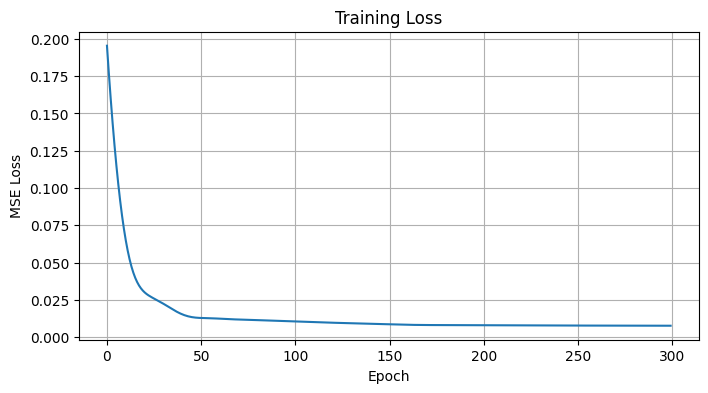

In [5]:

plt.figure(figsize=(8, 4))
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()


In [6]:

model.eval()
with torch.no_grad():
    y_pred_train_scaled = model(X_train_t).cpu().numpy()
    y_pred_test_scaled = model(X_test_t).cpu().numpy()

y_pred_train = y_scaler.inverse_transform(y_pred_train_scaled)
y_pred_test = y_scaler.inverse_transform(y_pred_test_scaled)

train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, y_pred_test)
train_rmse = math.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse = math.sqrt(mean_squared_error(y_test, y_pred_test))
test_r2 = r2_score(y_test, y_pred_test)

print("Train MAE :", round(train_mae, 3))
print("Test MAE  :", round(test_mae, 3))
print("Train RMSE:", round(train_rmse, 3))
print("Test RMSE :", round(test_rmse, 3))
print("Test R2   :", round(test_r2, 3))


Train MAE : 5.674
Test MAE  : 5.735
Train RMSE: 6.801
Test RMSE : 6.873
Test R2   : 0.776


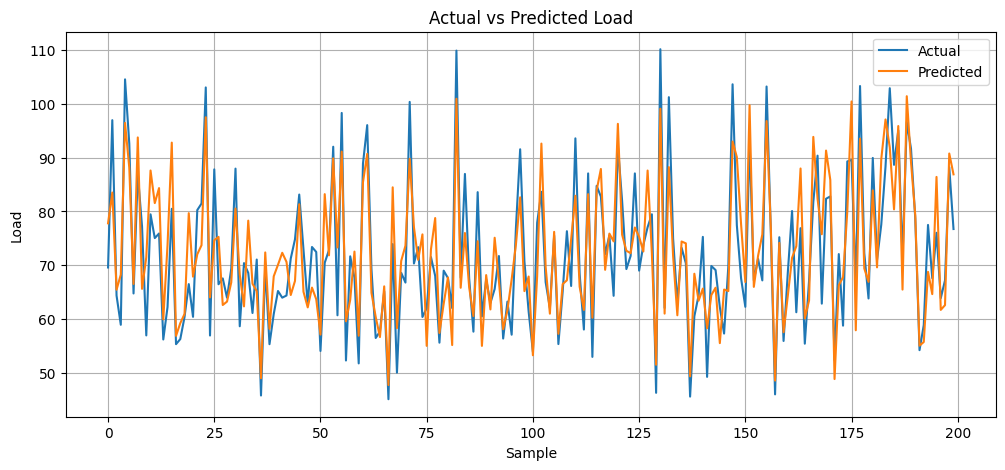

In [7]:

sample_idx = np.arange(min(200, len(y_test)))

plt.figure(figsize=(12, 5))
plt.plot(sample_idx, y_test[:len(sample_idx)], label="Actual")
plt.plot(sample_idx, y_pred_test[:len(sample_idx)], label="Predicted")
plt.title("Actual vs Predicted Load")
plt.xlabel("Sample")
plt.ylabel("Load")
plt.legend()
plt.grid(True)
plt.show()


In [8]:

def predict_load(hour, temperature, day_type):
    x_new = np.array([[hour, temperature, day_type]], dtype=float)
    x_new_scaled = x_scaler.transform(x_new)
    x_new_t = torch.tensor(x_new_scaled, dtype=torch.float32).to(device)

    model.eval()
    with torch.no_grad():
        y_new_scaled = model(x_new_t).cpu().numpy()

    y_new = y_scaler.inverse_transform(y_new_scaled)
    return float(y_new[0, 0])

print("Prediksi beban untuk jam 19, suhu 31C, weekday:")
print(round(predict_load(19, 31, 0), 2))

print("Prediksi beban untuk jam 14, suhu 30C, weekend:")
print(round(predict_load(14, 30, 1), 2))


Prediksi beban untuk jam 19, suhu 31C, weekday:
87.79
Prediksi beban untuk jam 14, suhu 30C, weekend:
70.97


In [9]:

import joblib

torch.save(model.state_dict(), "simple_anfis_load_forecasting.pth")
joblib.dump(x_scaler, "x_scaler.save")
joblib.dump(y_scaler, "y_scaler.save")

print("Model dan scaler berhasil disimpan.")


Model dan scaler berhasil disimpan.
